# 🎯 Offline Multi-Object Tracking with Missing Frame Prediction
## Using VisDrone2019-MOT Dataset

**Objective:** Build a research-quality offline tracking system that simulates missing detections and recovers trajectories using classical + ML techniques with hybrid decision fusion.

**Key Approach:**
- NO object detection model is used
- Ground-truth bounding boxes from VisDrone annotations
- Simulate missing frames (dropped detections)
- Predict bounding boxes for missing frames using hybrid methods
- Evaluate with IoU, Center Error, and Track Smoothness

## 1. Imports & Setup

In [1]:
import os
import glob
import csv
import random
import warnings
import numpy as np

# NumPy 2.0 compatibility polyfill for motmetrics
if not hasattr(np, 'asfarray'):
    np.asfarray = lambda x, **kwargs: np.asarray(x, dtype=float, **kwargs)
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
from copy import deepcopy

from filterpy.kalman import KalmanFilter
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# ── Configuration ──────────────────────────────────────────
DATASET_ROOT = r"VisDrone2019-MOT-train"
SEQ_DIR      = os.path.join(DATASET_ROOT, "sequences")
ANN_DIR      = os.path.join(DATASET_ROOT, "annotations")
OUTPUT_DIR   = "tracking_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Missing-frame simulation parameters
RANDOM_DROP_RATE    = 0.05   # 25% random drop
CONTINUOUS_GAP_MIN  = 2      # minimum gap length
CONTINUOUS_GAP_MAX  = 6      # maximum gap length
CONTINUOUS_GAP_PROB = 0.03   # probability of starting a gap

print("✅ All imports successful.")
print(f"📁 Dataset root : {os.path.abspath(DATASET_ROOT)}")
print(f"📁 Output dir   : {os.path.abspath(OUTPUT_DIR)}")
sequences = sorted(os.listdir(SEQ_DIR))
print(f"📊 Found {len(sequences)} sequences")

C:\Users\Vidhan\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ All imports successful.
📁 Dataset root : c:\Users\Vidhan\Documents\GitHub\ML_2026_7_ML_Code_Crafters\VisDrone2019-MOT-train
📁 Output dir   : c:\Users\Vidhan\Documents\GitHub\ML_2026_7_ML_Code_Crafters\tracking_output
📊 Found 56 sequences


## 2. Data Loading

In [2]:
def load_annotations(ann_path):
    """
    Load VisDrone MOT annotation file.
    Format: frame_idx, target_id, x, y, w, h, score, class, truncation, occlusion
    Returns dict: target_id -> [(frame_id, [x, y, w, h]), ...]
    """
    tracks = defaultdict(list)
    with open(ann_path, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) < 6:
                continue
            row = [v.strip() for v in row]
            frame_id  = int(row[0])
            target_id = int(row[1])
            x, y, w, h = float(row[2]), float(row[3]), float(row[4]), float(row[5])
            if w > 0 and h > 0:  # skip invalid boxes
                tracks[target_id].append((frame_id, [x, y, w, h]))
    return dict(tracks)


def get_frame_paths(seq_dir):
    """Get sorted list of frame image paths for a sequence."""
    patterns = [os.path.join(seq_dir, f"*.{ext}") for ext in ["jpg", "png", "bmp"]]
    paths = []
    for p in patterns:
        paths.extend(glob.glob(p))
    return sorted(paths)


def load_sequence(seq_name):
    """Load annotations and frame paths for one sequence."""
    ann_path = os.path.join(ANN_DIR, seq_name + ".txt")
    seq_path = os.path.join(SEQ_DIR, seq_name)
    tracks = load_annotations(ann_path)
    frames = get_frame_paths(seq_path)
    return tracks, frames


# Quick test
test_seq = sequences[0]
tracks_test, frames_test = load_sequence(test_seq)
print(f"Sequence: {test_seq}")
print(f"  Frames on disk : {len(frames_test)}")
print(f"  Unique tracks  : {len(tracks_test)}")
for tid in sorted(tracks_test.keys())[:5]:
    fids = [t[0] for t in tracks_test[tid]]
    print(f"    Track {tid}: {len(fids)} detections, frames {min(fids)}-{max(fids)}")

Sequence: uav0000013_00000_v
  Frames on disk : 269
  Unique tracks  : 60
    Track 0: 269 detections, frames 1-269
    Track 1: 195 detections, frames 1-195
    Track 2: 177 detections, frames 1-177
    Track 3: 179 detections, frames 1-179
    Track 4: 117 detections, frames 1-117


## 3. Track Construction

In [3]:
def build_sorted_tracks(raw_tracks):
    """
    Sort each track temporally and return a clean dict:
      track_id -> [(frame_id, bbox), ...] sorted by frame_id
    """
    sorted_tracks = {}
    for tid, detections in raw_tracks.items():
        sorted_dets = sorted(detections, key=lambda d: d[0])
        # Remove duplicates (keep first occurrence per frame)
        seen = set()
        unique = []
        for fid, bbox in sorted_dets:
            if fid not in seen:
                seen.add(fid)
                unique.append((fid, bbox))
        if len(unique) >= 2:  # need at least 2 points for prediction
            sorted_tracks[tid] = unique
    return sorted_tracks


def get_track_stats(tracks):
    """Print summary statistics for a set of tracks."""
    lengths = [len(v) for v in tracks.values()]
    spans = [v[-1][0] - v[0][0] + 1 for v in tracks.values()]
    print(f"  Total tracks    : {len(tracks)}")
    print(f"  Avg detections  : {np.mean(lengths):.1f}")
    print(f"  Avg span (frms) : {np.mean(spans):.1f}")
    print(f"  Min/Max length  : {min(lengths)}/{max(lengths)}")
    return lengths, spans


tracks_sorted = build_sorted_tracks(tracks_test)
print(f"Sequence: {test_seq}")
_ = get_track_stats(tracks_sorted)

Sequence: uav0000013_00000_v
  Total tracks    : 58
  Avg detections  : 148.5
  Avg span (frms) : 152.9
  Min/Max length  : 3/269


## 4. Missing Frame Simulation

Two strategies:
- **(A) Random Drop** — randomly remove ~25% of detections
- **(B) Continuous Gap Drop** — remove consecutive frames to simulate occlusion/tracking loss

In [4]:
def simulate_random_drop(tracks, drop_rate=0.25):
    """
    Randomly drop detections from each track.
    Returns: (observed_tracks, dropped_gt)
      - observed_tracks: track_id -> [(fid, bbox), ...] (remaining)
      - dropped_gt:      track_id -> {fid: bbox} (ground truth for dropped)
    """
    observed, dropped_gt = {}, {}
    for tid, dets in tracks.items():
        n = len(dets)
        if n < 4:
            observed[tid] = dets[:]
            dropped_gt[tid] = {}
            continue
        # Keep first and last frame to anchor the track
        keep = [True] * n
        for i in range(1, n - 1):
            if random.random() < drop_rate:
                keep[i] = False
        observed[tid] = [d for d, k in zip(dets, keep) if k]
        dropped_gt[tid] = {d[0]: d[1] for d, k in zip(dets, keep) if not k}
    return observed, dropped_gt


def simulate_continuous_gap(tracks, gap_min=2, gap_max=6, gap_prob=0.15):
    """
    Simulate continuous gaps (e.g., frames 11-12 missing between 10 and 13).
    Returns: (observed_tracks, dropped_gt)
    """
    observed, dropped_gt = {}, {}
    for tid, dets in tracks.items():
        n = len(dets)
        if n < gap_min + 4:
            observed[tid] = dets[:]
            dropped_gt[tid] = {}
            continue
        keep = [True] * n
        i = 1
        while i < n - 2:
            if random.random() < gap_prob:
                upper = min(gap_max, n - i - 2)
                if upper < gap_min:
                    i += 1
                    continue
                gap_len = random.randint(gap_min, upper)
                for j in range(i, min(i + gap_len, n - 1)):
                    keep[j] = False
                i += gap_len + 1
            else:
                i += 1
        observed[tid] = [d for d, k in zip(dets, keep) if k]
        dropped_gt[tid] = {d[0]: d[1] for d, k in zip(dets, keep) if not k}
    return observed, dropped_gt


def simulate_combined_drop(tracks, drop_rate=0.15, gap_min=2, gap_max=6, gap_prob=0.10):
    """Apply both random and continuous gap drops for a realistic scenario."""
    obs1, gt1 = simulate_random_drop(tracks, drop_rate * 0.6)
    obs2, gt2 = simulate_continuous_gap(obs1, gap_min, gap_max, gap_prob)
    # Merge ground truths
    all_gt = {}
    for tid in tracks:
        merged = {}
        if tid in gt1:
            merged.update(gt1[tid])
        if tid in gt2:
            merged.update(gt2[tid])
        all_gt[tid] = merged
    return obs2, all_gt


# Demo
obs_tracks, gt_dropped = simulate_combined_drop(tracks_sorted)
total_orig = sum(len(v) for v in tracks_sorted.values())
total_dropped = sum(len(v) for v in gt_dropped.values())
total_kept = sum(len(v) for v in obs_tracks.values())
print(f"Original detections : {total_orig}")
print(f"Dropped detections  : {total_dropped} ({100*total_dropped/total_orig:.1f}%)")
print(f"Kept detections     : {total_kept}")

Original detections : 8612
Dropped detections  : 2881 (33.5%)
Kept detections     : 5731


## 5. Feature Extraction

In [5]:
def extract_velocity(track):
    """
    Compute velocity (vx, vy) between consecutive frames.
    Returns list of (frame_id, vx, vy, dw, dh) tuples.
    """
    velocities = []
    for i in range(1, len(track)):
        fid_prev, bbox_prev = track[i-1]
        fid_curr, bbox_curr = track[i]
        dt = fid_curr - fid_prev
        if dt == 0:
            continue
        vx = (bbox_curr[0] - bbox_prev[0]) / dt
        vy = (bbox_curr[1] - bbox_prev[1]) / dt
        dw = (bbox_curr[2] - bbox_prev[2]) / dt
        dh = (bbox_curr[3] - bbox_prev[3]) / dt
        velocities.append((fid_curr, vx, vy, dw, dh))
    return velocities


def extract_acceleration(velocities):
    """Compute acceleration from velocity list."""
    accels = []
    for i in range(1, len(velocities)):
        fid = velocities[i][0]
        ax = velocities[i][1] - velocities[i-1][1]
        ay = velocities[i][2] - velocities[i-1][2]
        accels.append((fid, ax, ay))
    return accels


def compute_track_features(track):
    """Compute all features for a single track."""
    vels = extract_velocity(track)
    accels = extract_acceleration(vels)
    avg_vel = np.mean([[v[1], v[2]] for v in vels], axis=0) if vels else [0, 0]
    avg_size = np.mean([d[1][2:] for d in track], axis=0)
    return {
        'velocities': vels,
        'accelerations': accels,
        'avg_velocity': avg_vel,
        'avg_size': avg_size
    }


# Demo on a sample track
sample_tid = list(obs_tracks.keys())[0]
sample_feats = compute_track_features(obs_tracks[sample_tid])
print(f"Track {sample_tid}:")
print(f"  Avg velocity : ({sample_feats['avg_velocity'][0]:.2f}, {sample_feats['avg_velocity'][1]:.2f})")
print(f"  Avg size     : ({sample_feats['avg_size'][0]:.1f}, {sample_feats['avg_size'][1]:.1f})")
print(f"  # velocities : {len(sample_feats['velocities'])}")

Track 0:
  Avg velocity : (0.12, -0.09)
  Avg size     : (171.1, 185.9)
  # velocities : 177


## 6. Prediction Methods

### 6A. Linear Interpolation (Baseline)

In [6]:
def predict_linear_interpolation(track, missing_frames):
    """
    Linearly interpolate bounding boxes for missing frames 
    between known anchor points.
    """
    predictions = {}
    if len(track) < 2:
        return predictions
    fids = [d[0] for d in track]
    for mf in missing_frames:
        # Find surrounding anchor frames
        left_idx = None
        right_idx = None
        for i, fid in enumerate(fids):
            if fid < mf:
                left_idx = i
            elif fid > mf and right_idx is None:
                right_idx = i
                break
        if left_idx is not None and right_idx is not None:
            f1, b1 = track[left_idx]
            f2, b2 = track[right_idx]
            alpha = (mf - f1) / (f2 - f1) if f2 != f1 else 0.5
            pred = [b1[j] + alpha * (b2[j] - b1[j]) for j in range(4)]
            predictions[mf] = pred
        elif left_idx is not None:
            # Extrapolate forward
            if left_idx > 0:
                f0, b0 = track[left_idx - 1]
                f1, b1 = track[left_idx]
                dt_ref = f1 - f0 if f1 != f0 else 1
                dt = mf - f1
                pred = [b1[j] + (b1[j] - b0[j]) / dt_ref * dt for j in range(4)]
                predictions[mf] = pred
            else:
                predictions[mf] = list(track[left_idx][1])
        elif right_idx is not None:
            if right_idx < len(track) - 1:
                f1, b1 = track[right_idx]
                f2, b2 = track[right_idx + 1]
                dt_ref = f2 - f1 if f2 != f1 else 1
                dt = mf - f1
                pred = [b1[j] + (b1[j] - b2[j]) / dt_ref * dt for j in range(4)]
                predictions[mf] = pred
            else:
                predictions[mf] = list(track[right_idx][1])
    return predictions


# Quick test
test_track = obs_tracks[sample_tid]
test_missing = sorted(gt_dropped[sample_tid].keys())[:5]
test_interp = predict_linear_interpolation(test_track, test_missing)
print(f"Interpolation predictions for track {sample_tid}:")
for fid, bbox in sorted(test_interp.items()):
    gt = gt_dropped[sample_tid].get(fid)
    print(f"  Frame {fid}: pred={[f'{v:.1f}' for v in bbox]}, gt={gt}")

Interpolation predictions for track 0:
  Frame 2: pred=['592.8', '43.0', '174.0', '189.8'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 3: pred=['592.6', '43.0', '174.0', '189.6'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 4: pred=['592.4', '43.0', '174.0', '189.4'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 5: pred=['592.2', '43.0', '174.0', '189.2'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 8: pred=['590.9', '43.0', '174.0', '189.0'], gt=[591.0, 43.0, 174.0, 189.0]


### 6B. Kalman Filter (Main Method)

In [7]:
def create_kalman_filter(initial_bbox, dt=1.0):
    """
    Create a Kalman filter for tracking.
    State: [x, y, vx, vy, w, h]
    Measurement: [x, y, w, h]
    """
    kf = KalmanFilter(dim_x=6, dim_z=4)
    
    # State transition matrix (constant velocity model)
    kf.F = np.array([
        [1, 0, dt, 0,  0, 0],
        [0, 1, 0,  dt, 0, 0],
        [0, 0, 1,  0,  0, 0],
        [0, 0, 0,  1,  0, 0],
        [0, 0, 0,  0,  1, 0],
        [0, 0, 0,  0,  0, 1]
    ])
    
    # Measurement matrix
    kf.H = np.array([
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1]
    ])
    
    # Measurement noise
    kf.R *= 10.0
    
    # Process noise
    kf.Q[0:2, 0:2] *= 1.0
    kf.Q[2:4, 2:4] *= 5.0
    kf.Q[4:6, 4:6] *= 0.5
    
    # Initial covariance
    kf.P *= 100.0
    kf.P[2:4, 2:4] *= 10.0
    
    # Initial state
    kf.x = np.array([
        initial_bbox[0], initial_bbox[1],
        0, 0,
        initial_bbox[2], initial_bbox[3]
    ]).reshape(6, 1)
    
    return kf


def predict_kalman(track, missing_frames):
    """
    Use Kalman filter to predict bounding boxes for missing frames.
    Process frames in temporal order, predicting or updating as needed.
    """
    if len(track) < 2:
        return {}
    
    predictions = {}
    missing_set = set(missing_frames)
    
    # Build a timeline: all frames from first to last
    all_observed = {d[0]: d[1] for d in track}
    first_frame = track[0][0]
    last_frame = track[-1][0]
    
    # Initialize Kalman filter with first observation
    kf = create_kalman_filter(track[0][1])
    
    # Also update with first observation
    kf.update(np.array([
        track[0][1][0], track[0][1][1],
        track[0][1][2], track[0][1][3]
    ]).reshape(4, 1))
    
    prev_frame = first_frame
    
    for fid in range(first_frame + 1, last_frame + 1):
        # Update F matrix for variable dt
        dt = fid - prev_frame
        kf.F[0, 2] = dt
        kf.F[1, 3] = dt
        
        kf.predict()
        
        if fid in all_observed:
            # We have a measurement — update
            bbox = all_observed[fid]
            kf.update(np.array([bbox[0], bbox[1], bbox[2], bbox[3]]).reshape(4, 1))
        
        if fid in missing_set:
            state = kf.x.flatten()
            pred_bbox = [state[0], state[1], max(state[4], 1), max(state[5], 1)]
            predictions[fid] = pred_bbox
        
        prev_frame = fid
    
    return predictions


# Test Kalman predictions
test_kalman = predict_kalman(test_track, test_missing)
print(f"Kalman predictions for track {sample_tid}:")
for fid in sorted(test_kalman.keys()):
    pred = test_kalman[fid]
    gt = gt_dropped[sample_tid].get(fid)
    print(f"  Frame {fid}: pred={[f'{v:.1f}' for v in pred]}, gt={gt}")

Kalman predictions for track 0:
  Frame 2: pred=['593.0', '43.0', '174.0', '190.0'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 3: pred=['593.0', '43.0', '174.0', '190.0'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 4: pred=['593.0', '43.0', '174.0', '190.0'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 5: pred=['593.0', '43.0', '174.0', '190.0'], gt=[592.0, 43.0, 174.0, 189.0]
  Frame 8: pred=['590.7', '43.0', '174.0', '189.3'], gt=[591.0, 43.0, 174.0, 189.0]


### 6C. Spatio-Temporal Constraints

In [8]:
def apply_spatiotemporal_constraints(predictions, track, max_vel_jump=50, max_size_change=0.5):
    """
    Apply spatio-temporal constraints to smooth predictions.
    - Limit sudden velocity jumps
    - Maintain size consistency
    """
    if not predictions or len(track) < 2:
        return predictions
    
    # Compute average velocity and size from observed track
    vels = extract_velocity(track)
    if not vels:
        return predictions
    
    avg_vx = np.mean([v[1] for v in vels])
    avg_vy = np.mean([v[2] for v in vels])
    avg_w = np.mean([d[1][2] for d in track])
    avg_h = np.mean([d[1][3] for d in track])
    
    smoothed = {}
    prev_bbox = None
    prev_fid = None
    
    # Get the last observed bbox before predictions
    obs_dict = {d[0]: d[1] for d in track}
    
    for fid in sorted(predictions.keys()):
        pred = list(predictions[fid])
        
        # Find closest prior observed frame
        if prev_bbox is None:
            for d in reversed(track):
                if d[0] < fid:
                    prev_bbox = d[1]
                    prev_fid = d[0]
                    break
        
        if prev_bbox is not None and prev_fid is not None:
            dt = fid - prev_fid
            if dt > 0:
                vx = (pred[0] - prev_bbox[0]) / dt
                vy = (pred[1] - prev_bbox[1]) / dt
                
                # Clamp velocity jumps
                if abs(vx - avg_vx) > max_vel_jump:
                    pred[0] = prev_bbox[0] + avg_vx * dt
                if abs(vy - avg_vy) > max_vel_jump:
                    pred[1] = prev_bbox[1] + avg_vy * dt
        
        # Size consistency: don't let w/h deviate too much from average
        if pred[2] < avg_w * (1 - max_size_change):
            pred[2] = avg_w * (1 - max_size_change)
        if pred[2] > avg_w * (1 + max_size_change):
            pred[2] = avg_w * (1 + max_size_change)
        if pred[3] < avg_h * (1 - max_size_change):
            pred[3] = avg_h * (1 - max_size_change)
        if pred[3] > avg_h * (1 + max_size_change):
            pred[3] = avg_h * (1 + max_size_change)
        
        # Ensure positive w, h
        pred[2] = max(pred[2], 1)
        pred[3] = max(pred[3], 1)
        
        smoothed[fid] = pred
        prev_bbox = pred
        prev_fid = fid
    
    return smoothed


# Test constraints
kalman_smoothed = apply_spatiotemporal_constraints(test_kalman, test_track)
print("After spatio-temporal smoothing:")
for fid in sorted(kalman_smoothed.keys()):
    print(f"  Frame {fid}: {[f'{v:.1f}' for v in kalman_smoothed[fid]]}")

After spatio-temporal smoothing:
  Frame 2: ['593.0', '43.0', '174.0', '190.0']
  Frame 3: ['593.0', '43.0', '174.0', '190.0']
  Frame 4: ['593.0', '43.0', '174.0', '190.0']
  Frame 5: ['593.0', '43.0', '174.0', '190.0']
  Frame 8: ['590.7', '43.0', '174.0', '189.3']


### 6D. ML-Based Prediction (Extension)

In [ ]:
def prepare_ml_training_data(all_tracks):
    """
    Prepare training data from all tracks.
    Input features: [x, y, w, h, vx, vy, gap_size]
    Output: [x_pred, y_pred, w_pred, h_pred]
    """
    X, y = [], []
    for tid, track in all_tracks.items():
        if len(track) < 5:
            continue
        for gap in [1, 2, 3, 4, 5]:
            for i in range(len(track) - gap - 1):
                fid_before, bbox_before = track[i]
                fid_after, bbox_after = track[i + gap + 1] if i + gap + 1 < len(track) else (None, None)
                fid_target, bbox_target = track[i + 1]
                
                if fid_after is None:
                    continue
                
                dt = fid_target - fid_before
                if dt == 0:
                    continue
                
                # Velocity from previous step
                if i > 0:
                    fid_pp, bbox_pp = track[i - 1]
                    dt_prev = fid_before - fid_pp if fid_before != fid_pp else 1
                    vx = (bbox_before[0] - bbox_pp[0]) / dt_prev
                    vy = (bbox_before[1] - bbox_pp[1]) / dt_prev
                else:
                    vx, vy = 0.0, 0.0
                
                features = bbox_before + [vx, vy, float(gap)]
                target = bbox_target
                X.append(features)
                y.append(target)
    
    return np.array(X), np.array(y)


def train_ml_models(X, y):
    """Train Linear Regression and Random Forest models."""
    if len(X) < 20:
        print("Not enough training data for ML models")
        return None, None
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_score = lr.score(X_test, y_test)
    print(f"  Linear Regression  R²: {lr_score:.4f}")
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_score = rf.score(X_test, y_test)
    print(f"  Random Forest      R²: {rf_score:.4f}")
    
    return lr, rf


def predict_ml(track, missing_frames, model):
    """Use ML model to predict missing bounding boxes."""
    if model is None or len(track) < 2:
        return {}
    
    predictions = {}
    obs_dict = {d[0]: d[1] for d in track}
    vels = extract_velocity(track)
    vel_dict = {v[0]: (v[1], v[2]) for v in vels}
    
    for mf in missing_frames:
        # Find the closest prior observed frame
        best_prior = None
        for fid, bbox in reversed(track):
            if fid < mf:
                best_prior = (fid, bbox)
                break
        if best_prior is None:
            continue
        
        fid_p, bbox_p = best_prior
        gap = mf - fid_p
        
        # Get velocity at prior frame
        vx, vy = vel_dict.get(fid_p, (0.0, 0.0))
        
        features = np.array([bbox_p + [vx, vy, float(gap)]]).reshape(1, -1)
        pred = model.predict(features)[0]
        pred = [max(v, 0) for v in pred]
        pred[2] = max(pred[2], 1)
        pred[3] = max(pred[3], 1)
        predictions[mf] = list(pred)
    
    return predictions


# Train ML models on all tracks from first sequence
print("Training ML models...")
X_ml, y_ml = prepare_ml_training_data(tracks_sorted)
print(f"  Training samples: {len(X_ml)}")
lr_model, rf_model = train_ml_models(X_ml, y_ml)

Training ML models...
  Training samples: 41905
  Linear Regression  R²: 0.9995
  Random Forest      R²: 0.9942


## 7. Decision Fusion

Combine predictions intelligently based on gap size:
- **Small gap (1-2 frames):** Linear interpolation (most accurate for short gaps)
- **Medium gap (3-5 frames):** Kalman filter with spatio-temporal constraints
- **Large gap (6+ frames):** Weighted fusion of Kalman + ML

In [10]:
def classify_gap_size(track, missing_frame):
    """Determine gap size category for a missing frame within a track."""
    fids = [d[0] for d in track]
    # Find the surrounding observed frames
    left = max((f for f in fids if f < missing_frame), default=None)
    right = min((f for f in fids if f > missing_frame), default=None)
    
    if left is not None and right is not None:
        gap = right - left - 1
    elif left is not None:
        gap = missing_frame - left
    elif right is not None:
        gap = right - missing_frame
    else:
        gap = 10  # fallback
    
    if gap <= 2:
        return 'small', gap
    elif gap <= 5:
        return 'medium', gap
    else:
        return 'large', gap


def decision_fusion(track, missing_frames, ml_model=None):
    """
    Hybrid decision fusion for predicting missing bounding boxes.
    Strategy:
      small  gap → Interpolation
      medium gap → Kalman + Spatio-temporal
      large  gap → Weighted: 0.6*Kalman + 0.2*Interp + 0.2*ML
    """
    # Get predictions from all methods
    interp_preds = predict_linear_interpolation(track, missing_frames)
    kalman_preds = predict_kalman(track, missing_frames)
    kalman_preds = apply_spatiotemporal_constraints(kalman_preds, track)
    ml_preds = predict_ml(track, missing_frames, ml_model) if ml_model else {}
    
    final_preds = {}
    method_used = {}
    
    for mf in missing_frames:
        gap_type, gap_size = classify_gap_size(track, mf)
        
        if gap_type == 'small' and mf in interp_preds:
            final_preds[mf] = interp_preds[mf]
            method_used[mf] = 'interpolation'
        
        elif gap_type == 'medium':
            if mf in kalman_preds:
                final_preds[mf] = kalman_preds[mf]
                method_used[mf] = 'kalman'
            elif mf in interp_preds:
                final_preds[mf] = interp_preds[mf]
                method_used[mf] = 'interpolation(fallback)'
        
        elif gap_type == 'large':
            available = []
            weights = []
            if mf in kalman_preds:
                available.append(kalman_preds[mf])
                weights.append(0.6)
            if mf in interp_preds:
                available.append(interp_preds[mf])
                weights.append(0.2)
            if mf in ml_preds:
                available.append(ml_preds[mf])
                weights.append(0.2)
            
            if available:
                # Normalize weights
                w_sum = sum(weights)
                weights = [w / w_sum for w in weights]
                fused = [0.0] * 4
                for pred, w in zip(available, weights):
                    for j in range(4):
                        fused[j] += w * pred[j]
                final_preds[mf] = fused
                method_used[mf] = 'fusion'
            elif mf in kalman_preds:
                final_preds[mf] = kalman_preds[mf]
                method_used[mf] = 'kalman(fallback)'
        
        else:
            # Default fallback
            if mf in kalman_preds:
                final_preds[mf] = kalman_preds[mf]
                method_used[mf] = 'kalman(default)'
            elif mf in interp_preds:
                final_preds[mf] = interp_preds[mf]
                method_used[mf] = 'interp(default)'
    
    return final_preds, method_used


# Test decision fusion
test_missing_all = sorted(gt_dropped[sample_tid].keys())
fused_preds, methods = decision_fusion(test_track, test_missing_all, rf_model)
print(f"Decision fusion for track {sample_tid}:")
method_counts = defaultdict(int)
for m in methods.values():
    method_counts[m] += 1
for m, c in method_counts.items():
    print(f"  {m}: {c} frames")
print(f"  Total predicted: {len(fused_preds)}/{len(test_missing_all)} missing frames")

Decision fusion for track 0:
  kalman: 47 frames
  fusion: 29 frames
  interpolation: 15 frames
  Total predicted: 91/91 missing frames


## 8. Track Continuity Logic

In [11]:
def handle_track_continuity(track, predictions, max_extrapolation=10, min_track_length=3):
    """
    Handle edge cases:
    - Track start/end extrapolation limits
    - Long missing gap termination
    - Unstable prediction filtering
    """
    if len(track) < min_track_length:
        return {}
    
    first_obs = track[0][0]
    last_obs = track[-1][0]
    
    filtered = {}
    for fid, bbox in predictions.items():
        # Don't extrapolate too far before/after observed range
        if fid < first_obs - max_extrapolation:
            continue
        if fid > last_obs + max_extrapolation:
            continue
        
        # Filter out negative or unreasonably large bboxes
        if bbox[0] < -100 or bbox[1] < -100:
            continue
        if bbox[2] > 2000 or bbox[3] > 2000:
            continue
        if bbox[2] < 1 or bbox[3] < 1:
            continue
        
        filtered[fid] = bbox
    
    return filtered


# Apply track continuity
cont_preds = handle_track_continuity(test_track, fused_preds)
print(f"After continuity filtering: {len(cont_preds)}/{len(fused_preds)} predictions retained")

After continuity filtering: 91/91 predictions retained


## 9. Evaluation Metrics

In [12]:
import motmetrics as mm

def compute_iou(bbox1, bbox2):
    """Compute Intersection over Union for two bboxes [x, y, w, h]."""
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2
    
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    
    inter_w = max(0, xi2 - xi1)
    inter_h = max(0, yi2 - yi1)
    inter_area = inter_w * inter_h
    
    area1 = w1 * h1
    area2 = w2 * h2
    union_area = area1 + area2 - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0


def compute_center_error(bbox1, bbox2):
    """Compute center distance (MSE) between two bboxes."""
    cx1 = bbox1[0] + bbox1[2] / 2
    cy1 = bbox1[1] + bbox1[3] / 2
    cx2 = bbox2[0] + bbox2[2] / 2
    cy2 = bbox2[1] + bbox2[3] / 2
    return np.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)


def compute_track_smoothness(predictions_sorted):
    """
    Compute smoothness as average jerk (change in velocity).
    Lower = smoother.
    """
    if len(predictions_sorted) < 3:
        return 0.0
    bboxes = [p[1] for p in predictions_sorted]
    vels = []
    for i in range(1, len(bboxes)):
        vx = bboxes[i][0] - bboxes[i-1][0]
        vy = bboxes[i][1] - bboxes[i-1][1]
        vels.append((vx, vy))
    jerks = []
    for i in range(1, len(vels)):
        jx = vels[i][0] - vels[i-1][0]
        jy = vels[i][1] - vels[i-1][1]
        jerks.append(np.sqrt(jx**2 + jy**2))
    return np.mean(jerks) if jerks else 0.0



def compute_mot_metrics(all_predictions, all_gt, all_tracks):
    """
    Compute MOTA and IDF1 using motmetrics.
    all_predictions: dict {track_id: {frame_id: bbox}}
    all_gt: dict {track_id: {frame_id: bbox}}
    all_tracks: dict {track_id: [(frame_id, bbox), ...]}
    """
    acc = mm.MOTAccumulator(auto_id=True)
    
    # Get all frame IDs
    all_fids = set()
    for tr in all_tracks.values():
        for fid, _ in tr:
            all_fids.add(fid)
    
    for fid in sorted(list(all_fids)):
        gt_ids, gt_bboxes = [], []
        pred_ids, pred_bboxes = [], []
        
        # Collect ground truth for this frame
        for tid, tr in all_tracks.items():
            for f, b in tr:
                if f == fid:
                    gt_ids.append(tid)
                    gt_bboxes.append(b)
                    break
        
        # Collect predictions (or observations) for this frame
        # We consider a "detection" to be either an observation or a prediction
        for tid, preds in all_predictions.items():
            if fid in preds:
                pred_ids.append(tid)
                pred_bboxes.append(preds[fid])
            else:
                # If not predicted, check if it was originally an observation (not dropped)
                # This part is handled by comparing with the original track
                pass
                
        # Since we are doing trajectory reconstruction, the "tracker" output 
        # is the union of original observations + our predictions.
        # But for MOTA calculation against the FULL ground truth:
        # We need to know which bboxes are currently active for the tracker.
        
        # Distance matrix (1 - IoU)
        if not gt_bboxes or not pred_bboxes:
            distances = []
        else:
            # motmetrics expects [x, y, w, h] which we have
            distances = mm.distances.iou_matrix(gt_bboxes, pred_bboxes, max_iou=0.5)
        
        acc.update(gt_ids, pred_ids, distances)
    
    mh = mm.metrics.create()
    summary = mh.compute(acc, metrics=['mota', 'idf1', 'motp', 'precision', 'recall'], name='acc')
    return summary.to_dict('records')[0]

def evaluate_predictions(predictions, ground_truth):
    """
    Evaluate all predictions against ground truth.
    Returns per-frame and aggregate metrics.
    """
    ious, center_errors = [], []
    
    for fid in predictions:
        if fid in ground_truth:
            pred = predictions[fid]
            gt = ground_truth[fid]
            iou = compute_iou(pred, gt)
            ce = compute_center_error(pred, gt)
            ious.append(iou)
            center_errors.append(ce)
    
    results = {
        'avg_iou': np.mean(ious) if ious else 0.0,
        'median_iou': np.median(ious) if ious else 0.0,
        'avg_center_error': np.mean(center_errors) if center_errors else 0.0,
        'num_evaluated': len(ious),
        'ious': ious,
        'center_errors': center_errors
    }
    return results


# Evaluate sample track
eval_res = evaluate_predictions(cont_preds, gt_dropped[sample_tid])
print(f"Evaluation for track {sample_tid}:")
print(f"  Avg IoU          : {eval_res['avg_iou']:.4f}")
print(f"  Median IoU       : {eval_res['median_iou']:.4f}")
print(f"  Avg Center Error : {eval_res['avg_center_error']:.2f} px")
print(f"  Frames evaluated : {eval_res['num_evaluated']}")

Evaluation for track 0:
  Avg IoU          : 0.9748
  Median IoU       : 0.9858
  Avg Center Error : 1.51 px
  Frames evaluated : 91


## 10. Visualization

In [13]:
def draw_tracking_frame(frame_img, frame_id, gt_bboxes, pred_bboxes):
    """
    Draw ground truth (GREEN) and predicted (RED) bounding boxes on a frame.
    gt_bboxes:   dict {track_id: [x, y, w, h]}
    pred_bboxes: dict {track_id: [x, y, w, h]}
    """
    vis = frame_img.copy()
    
    # Draw ground truth in GREEN
    for tid, bbox in gt_bboxes.items():
        x, y, w, h = [int(v) for v in bbox]
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(vis, f"GT-{tid}", (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
    
    # Draw predictions in RED
    for tid, bbox in pred_bboxes.items():
        x, y, w, h = [int(v) for v in bbox]
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.putText(vis, f"P-{tid}", (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
    
    # Frame number
    cv2.putText(vis, f"Frame: {frame_id}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    
    return vis


def visualize_sequence_sample(seq_name, tracks, obs_tracks_seq, predictions_all, 
                               gt_dropped_seq, frame_paths, num_frames=5):
    """Visualize a few sample frames with GT and predictions overlaid."""
    # Find frames that have predictions
    pred_frames = set()
    for tid, preds in predictions_all.items():
        pred_frames.update(preds.keys())
    
    pred_frames = sorted(pred_frames)
    if not pred_frames:
        print("No predicted frames to visualize")
        return
    
    # Sample frames
    step = max(1, len(pred_frames) // num_frames)
    sample_frames = pred_frames[::step][:num_frames]
    
    fig, axes = plt.subplots(1, min(num_frames, len(sample_frames)), 
                              figsize=(6 * min(num_frames, len(sample_frames)), 5))
    if len(sample_frames) == 1:
        axes = [axes]
    
    for ax, fid in zip(axes, sample_frames):
        # Load frame image
        frame_idx = fid - 1  # frames are 1-indexed
        if frame_idx < 0 or frame_idx >= len(frame_paths):
            continue
        img = cv2.imread(frame_paths[frame_idx])
        if img is None:
            continue
        # img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Skipped to keep BGR for drawing
        
        # Collect GT and predicted bboxes for this frame
        gt_bboxes = {}
        pred_bboxes = {}
        
        for tid in tracks:
            # Original GT
            for f, b in tracks[tid]:
                if f == fid:
                    gt_bboxes[tid] = b
                    break
        
        for tid in predictions_all:
            if fid in predictions_all[tid]:
                pred_bboxes[tid] = predictions_all[tid][fid]
        
        # We keep the image in BGR for draw_tracking_frame to ensure (0,0,255) is RED
        vis_bgr = draw_tracking_frame(img, fid, gt_bboxes, pred_bboxes)
        vis = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(vis)
        ax.set_title(f"Frame {fid}")
        ax.axis('off')
    
    plt.suptitle(f"Sequence: {seq_name}  |  GREEN=GT  RED=Predicted", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"viz_{seq_name}.png"), dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved visualization to {OUTPUT_DIR}/viz_{seq_name}.png")

## 11. Video Output

In [14]:
def generate_output_video(seq_name, tracks_original, obs_tracks_seq,
                          predictions_all, gt_dropped_seq, frame_paths, 
                          fps=15, max_frames=None):
    """Generate output video with GT (green) and predicted (red) boxes."""
    if not frame_paths:
        print("No frames found!")
        return
    
    # Read first frame to get dimensions
    sample = cv2.imread(frame_paths[0])
    if sample is None:
        print(f"Cannot read frame: {frame_paths[0]}")
        return
    h, w = sample.shape[:2]
    
    output_path = os.path.join(OUTPUT_DIR, f"tracking_{seq_name}.mp4")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    n_frames = len(frame_paths) if max_frames is None else min(len(frame_paths), max_frames)
    
    for i in range(n_frames):
        fid = i + 1  # 1-indexed frames
        img = cv2.imread(frame_paths[i])
        if img is None:
            continue
        
        # Collect GT bboxes (observed)
        gt_bboxes = {}
        # From observed tracks
        for tid, dets in obs_tracks_seq.items():
            for f, b in dets:
                if f == fid:
                    gt_bboxes[tid] = b
                    break
        
        # Collect predicted bboxes
        pred_bboxes = {}
        for tid, preds in predictions_all.items():
            if fid in preds:
                pred_bboxes[tid] = preds[fid]
        
        vis = draw_tracking_frame(img, fid, gt_bboxes, pred_bboxes)
        writer.write(vis)
    
    writer.release()
    print(f"✅ Video saved: {output_path} ({n_frames} frames, {fps} fps)")
    return output_path

## 12. Main Pipeline Execution

Run the complete pipeline on selected sequences.

In [15]:
def run_pipeline(seq_name, ml_model=None, generate_video=True, max_video_frames=200):
    """
    Complete pipeline for one sequence:
    1. Load data
    2. Build tracks
    3. Simulate missing frames
    4. Predict missing bboxes (decision fusion)
    5. Evaluate
    6. Visualize
    7. Generate video
    """
    print(f"\n{'='*70}")
    print(f"  Processing: {seq_name}")
    print(f"{'='*70}")
    
    # Step 1-2: Load & build tracks
    raw_tracks, frame_paths = load_sequence(seq_name)
    tracks = build_sorted_tracks(raw_tracks)
    print(f"\n📊 Track Statistics:")
    get_track_stats(tracks)
    
    # Step 3: Simulate missing frames
    obs_tracks_seq, gt_dropped_seq = simulate_combined_drop(tracks)
    total_orig = sum(len(v) for v in tracks.values())
    total_dropped = sum(len(v) for v in gt_dropped_seq.values())
    print(f"\n🎯 Missing Frame Simulation:")
    print(f"  Original: {total_orig}, Dropped: {total_dropped} ({100*total_dropped/total_orig:.1f}%)")
    
    # Step 4: Train ML model on this sequence if not provided
    local_ml = ml_model
    if local_ml is None:
        X, y = prepare_ml_training_data(tracks)
        if len(X) > 20:
            _, local_ml = train_ml_models(X, y)
    
    # Step 5: Predict for each track
    all_predictions = {}
    all_methods = {}
    for tid in obs_tracks_seq:
        missing_frames = sorted(gt_dropped_seq.get(tid, {}).keys())
        if not missing_frames:
            continue
        preds, methods = decision_fusion(obs_tracks_seq[tid], missing_frames, local_ml)
        preds = handle_track_continuity(obs_tracks_seq[tid], preds)
        all_predictions[tid] = preds
        all_methods[tid] = methods
    
    # Method usage stats
    method_counts = defaultdict(int)
    for tid_methods in all_methods.values():
        for m in tid_methods.values():
            method_counts[m] += 1
    print(f"\n🔧 Prediction Methods Used:")
    for m, c in sorted(method_counts.items(), key=lambda x: -x[1]):
        print(f"  {m}: {c}")
    
    # Step 6: Evaluate
    all_ious = []
    all_ces = []
    track_results = {}
    for tid in all_predictions:
        if tid in gt_dropped_seq and gt_dropped_seq[tid]:
            res = evaluate_predictions(all_predictions[tid], gt_dropped_seq[tid])
            track_results[tid] = res
            all_ious.extend(res['ious'])
            all_ces.extend(res['center_errors'])
    
    
    # Step 6.5: Compute MOTA/IDF1
    mot_results = compute_mot_metrics(all_predictions, gt_dropped_seq, tracks)
    print(f"\n Evaluation Results:")
    if all_ious:
        print(f"  Average IoU          : {np.mean(all_ious):.4f}")
        print(f"  Median IoU           : {np.median(all_ious):.4f}")
        print(f"  Avg Center Error     : {np.mean(all_ces):.2f} px")
        print(f"  Median Center Error  : {np.median(all_ces):.2f} px")
        print(f"  Frames evaluated     : {len(all_ious)}")
        
        # Smoothness
        smooth_vals = []
        for tid, preds in all_predictions.items():
            sorted_preds = sorted(preds.items())
            s = compute_track_smoothness(sorted_preds)
            smooth_vals.append(s)
        print(f"  Avg Track Smoothness : {np.mean(smooth_vals):.2f} (lower=smoother)")

        print(f"  MOTA                 : {mot_results['mota']:.4f}")
        print(f"  IDF1                 : {mot_results['idf1']:.4f}")
    else:
        print("  No predictions to evaluate!")
    
    # Step 7: Visualize
    try:
        visualize_sequence_sample(seq_name, tracks, obs_tracks_seq, 
                                   all_predictions, gt_dropped_seq, frame_paths)
    except Exception as e:
        print(f"   Visualization error: {e}")
    
    # Step 8: Generate video
    video_path = None
    if generate_video:
        video_path = generate_output_video(seq_name, tracks, obs_tracks_seq,
                                            all_predictions, gt_dropped_seq,
                                            frame_paths, max_frames=max_video_frames)
    
    return {
        'tracks': tracks,
        'obs_tracks': obs_tracks_seq,
        'predictions': all_predictions,
        'ground_truth': gt_dropped_seq,
        'ious': all_ious,
        'center_errors': all_ces,
        'track_results': track_results,
        'mot_metrics': mot_results,
        'video_path': video_path
    }

## 13. Execute Pipeline


  Processing: uav0000248_00001_v

📊 Track Statistics:
  Total tracks    : 100
  Avg detections  : 328.3
  Avg span (frms) : 360.3
  Min/Max length  : 3/677

🎯 Missing Frame Simulation:
  Original: 32828, Dropped: 11572 (35.3%)

🔧 Prediction Methods Used:
  kalman: 4800
  fusion: 4212
  interpolation: 2560

📈 Evaluation Results:
  Average IoU          : 0.6673
  Median IoU           : 0.8927
  Avg Center Error     : 11.83 px
  Median Center Error  : 1.01 px
  Frames evaluated     : 11572
  Avg Track Smoothness : 9.41 (lower=smoother)
  MOTA                 : 0.1394
  IDF1                 : 0.3612


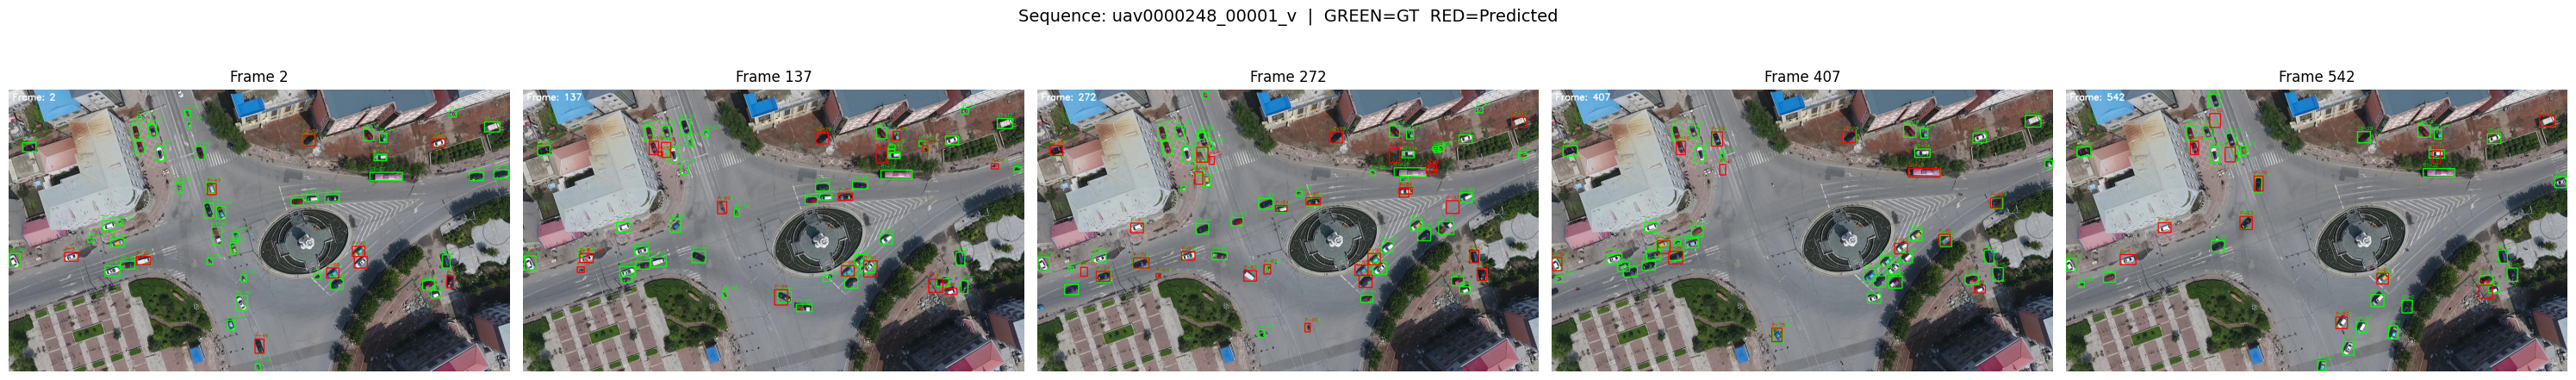

Saved visualization to tracking_output/viz_uav0000248_00001_v.png
✅ Video saved: tracking_output\tracking_uav0000248_00001_v.mp4 (200 frames, 15 fps)

  Processing: uav0000013_00000_v

📊 Track Statistics:
  Total tracks    : 58
  Avg detections  : 148.5
  Avg span (frms) : 152.9
  Min/Max length  : 3/269

🎯 Missing Frame Simulation:
  Original: 8612, Dropped: 2908 (33.8%)

🔧 Prediction Methods Used:
  fusion: 1148
  kalman: 1049
  interpolation: 711

📈 Evaluation Results:
  Average IoU          : 0.9001
  Median IoU           : 0.9276
  Avg Center Error     : 2.05 px
  Median Center Error  : 1.11 px
  Frames evaluated     : 2908
  Avg Track Smoothness : 6.68 (lower=smoother)
  MOTA                 : 0.3340
  IDF1                 : 0.5019


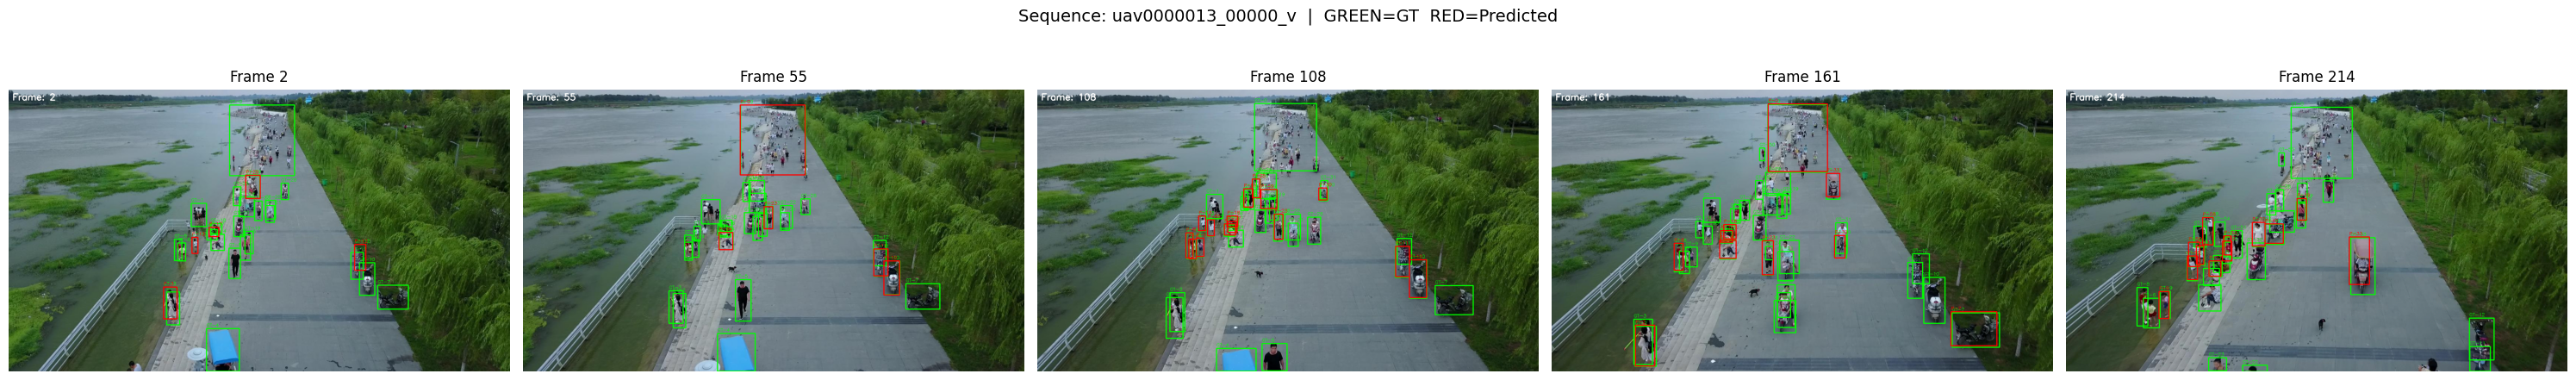

Saved visualization to tracking_output/viz_uav0000013_00000_v.png
✅ Video saved: tracking_output\tracking_uav0000013_00000_v.mp4 (200 frames, 15 fps)


In [16]:
# Run on first 3 sequences for demonstration
# Change the slice to process more/all sequences
sequences_to_process = ["uav0000248_00001_v", "uav0000013_00000_v"]

all_results = {}
for seq in sequences_to_process:
    result = run_pipeline(seq, ml_model=rf_model, generate_video=True, max_video_frames=200)
    all_results[seq] = result

## 14. Aggregate Results & Summary


  AGGREGATE RESULTS ACROSS ALL SEQUENCES

Sequence                               Avg IoU    Med IoU     Avg CE    #Frames       MOTA       IDF1
-------------------------------------------------------------------------------------------------
uav0000248_00001_v                      0.6673     0.8927      11.83      11572     0.1394     0.3612
uav0000013_00000_v                      0.9001     0.9276       2.05       2908     0.3340     0.5019
-------------------------------------------------------------------------------------------------
OVERALL                                 0.7141     0.9081       9.87      14480     0.2367     0.4315


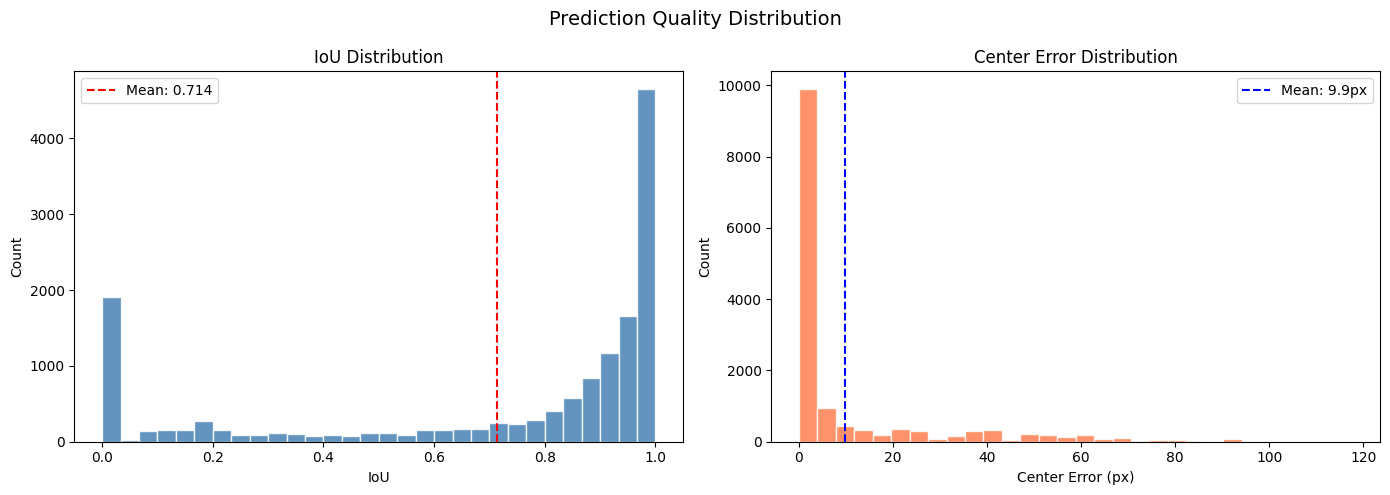


📊 Evaluation plot saved to tracking_output/evaluation_summary.png

✅ Pipeline complete!


In [17]:
print("\n" + "="*70)
print("  AGGREGATE RESULTS ACROSS ALL SEQUENCES")
print("="*70)

all_ious_global = []
all_ces_global = []

print(f"\n{'Sequence':<35} {'Avg IoU':>10} {'Med IoU':>10} {'Avg CE':>10} {'#Frames':>10} {'MOTA':>10} {'IDF1':>10}")
print("-" * 97)

for seq, res in all_results.items():
    if res['ious']:
        avg_iou = np.mean(res['ious'])
        med_iou = np.median(res['ious'])
        avg_ce = np.mean(res['center_errors'])
        n = len(res['ious'])
        mota = res['mot_metrics']['mota']
        idf1 = res['mot_metrics']['idf1']
        print(f"{seq:<35} {avg_iou:>10.4f} {med_iou:>10.4f} {avg_ce:>10.2f} {n:>10} {mota:>10.4f} {idf1:>10.4f}")
        all_ious_global.extend(res['ious'])
        all_ces_global.extend(res['center_errors'])

print("-" * 97)
if all_ious_global:
    avg_mota = np.mean([r['mot_metrics']['mota'] for r in all_results.values()])
    avg_idf1 = np.mean([r['mot_metrics']['idf1'] for r in all_results.values()])
    print(f"{'OVERALL':<35} {np.mean(all_ious_global):>10.4f} {np.median(all_ious_global):>10.4f} {np.mean(all_ces_global):>10.2f} {len(all_ious_global):>10} {avg_mota:>10.4f} {avg_idf1:>10.4f}")

# IoU distribution plot
if all_ious_global:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(all_ious_global, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(np.mean(all_ious_global), color='red', linestyle='--', label=f'Mean: {np.mean(all_ious_global):.3f}')
    axes[0].set_xlabel('IoU')
    axes[0].set_ylabel('Count')
    axes[0].set_title('IoU Distribution')
    axes[0].legend()
    
    axes[1].hist(all_ces_global, bins=30, color='coral', edgecolor='white', alpha=0.85)
    axes[1].axvline(np.mean(all_ces_global), color='blue', linestyle='--', label=f'Mean: {np.mean(all_ces_global):.1f}px')
    axes[1].set_xlabel('Center Error (px)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Center Error Distribution')
    axes[1].legend()
    
    plt.suptitle('Prediction Quality Distribution', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation_summary.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n Evaluation plot saved to {OUTPUT_DIR}/evaluation_summary.png")

print("\n Pipeline complete!")